In [1]:
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

In [2]:
from sklearn.preprocessing import StandardScaler,QuantileTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [34]:
df=pd.read_csv('data.csv')

In [35]:
df.isnull().sum()

Unnamed: 0        0
age               0
sex               0
current_smoker    0
heart_rate        0
blood_pressure    0
cigs_per_day      0
chol              0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0      3900 non-null   int64
 1   age             3900 non-null   int64
 2   sex             3900 non-null   int64
 3   current_smoker  3900 non-null   int64
 4   heart_rate      3900 non-null   int64
 5   blood_pressure  3900 non-null   str  
 6   cigs_per_day    3900 non-null   str  
 7   chol            3900 non-null   str  
dtypes: int64(5), str(3)
memory usage: 243.9 KB


In [6]:
df

,Unnamed: 0,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,0,54,1,1,95,110/72,<bound method Series.mean of 0 NaN\n1 ...,219.0
1,1,45,1,1,64,121/72,<bound method Series.mean of 0 NaN\n1 ...,248.0
2,2,58,1,1,81,127.5/76,<bound method Series.mean of 0 NaN\n1 ...,235.0
3,3,42,1,1,90,122.5/80,<bound method Series.mean of 0 NaN\n1 ...,225.0
4,4,42,1,1,62,119/80,<bound method Series.mean of 0 NaN\n1 ...,226.0
...,...,...,...,...,...,...,...,...
3895,3895,37,1,1,88,122.5/82.5,60.0,254.0
3896,3896,49,1,1,70,123/75,60.0,213.0
3897,3897,56,1,1,70,125/79,60.0,246.0
3898,3898,50,1,1,85,134/95,60.0,340.0


In [7]:
cols=['blood_pressure','cigs_per_day','chol']

In [8]:
df[cols]=df[cols].apply(pd.to_numeric,errors='coerce')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      3900 non-null   int64  
 1   age             3900 non-null   int64  
 2   sex             3900 non-null   int64  
 3   current_smoker  3900 non-null   int64  
 4   heart_rate      3900 non-null   int64  
 5   blood_pressure  0 non-null      float64
 6   cigs_per_day    3886 non-null   float64
 7   chol            3893 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 243.9 KB


In [10]:
X=df[['age','sex','current_smoker','cigs_per_day']].fillna(0)

X=X.fillna(0)

In [11]:
y=df[['heart_rate','blood_pressure','chol']].fillna(0)
y=y.fillna(0)

In [12]:
model=KNeighborsClassifier()

In [13]:
pipe=Pipeline([('scaler',StandardScaler()),
               ('model', KNeighborsClassifier(n_neighbors=5))
              ])
pipe.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('model', KNeighborsClassifier())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': KNeighborsClassifier(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [14]:
mod=GridSearchCV(estimator=pipe,
             param_grid={'model__n_neighbors':[1,2,3,4,5,6,7,8,9,10]},
             cv=3
            )

In [15]:
mod.fit(X,y);
pd.DataFrame(mod.cv_results_)

/home/tonnie/environment/myenv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/tonnie/environment/myenv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/tonnie/environment/myenv/lib/python3.14/site-packages/sklearn/metrics/_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/home/tonnie/environment/myenv/lib/python3.14/site-packages/sklearn/pipeline.py", line 1135, in score
    return self.steps[-1][1].score(Xt, y, **score_params)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/tonnie/environment/myenv/lib/python3.14/site-packages/sklearn/neighbors/_classification.py", line 450, 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007905,0.001381,0.011065,0.002341,1,{'model__n_neighbors': 1},NaN,NaN,NaN,NaN,NaN,1
1,0.005418,0.000099,0.009937,0.001126,2,{'model__n_neighbors': 2},NaN,NaN,NaN,NaN,NaN,1
2,0.005050,0.000035,0.009341,0.000509,3,{'model__n_neighbors': 3},NaN,NaN,NaN,NaN,NaN,1
3,0.005729,0.000257,0.008871,0.000772,4,{'model__n_neighbors': 4},NaN,NaN,NaN,NaN,NaN,1
4,0.007440,0.001362,0.010478,0.001385,5,{'model__n_neighbors': 5},NaN,NaN,NaN,NaN,NaN,1
5,0.008231,0.000399,0.013512,0.000666,6,{'model__n_neighbors': 6},NaN,NaN,NaN,NaN,NaN,1
6,0.007536,0.000193,0.014000,0.001191,7,{'model__n_neighbors': 7},NaN,NaN,NaN,NaN,NaN,1
7,0.007671,0.001059,0.013339,0.000659,8,{'model__n_neighbors': 8},NaN,NaN,NaN,NaN,NaN,1
8,0.009488,0.001245,0.016437,0.002481,9,{'model__n_neighbors': 9},NaN,NaN,NaN,NaN,NaN,1
9,0.008388,0.000515,0.015895,0.000951,10,{'model__n_neighbors': 10},NaN,NaN,NaN,NaN,NaN,1


In [16]:
pred=mod.predict(X)

In [17]:
pred

array([[ 95.,   0., 219.],
       [ 83.,   0., 170.],
       [ 81.,   0., 235.],
       ...,
       [ 70.,   0., 246.],
       [ 85.,   0., 340.],
       [ 98.,   0., 210.]], shape=(3900, 3))

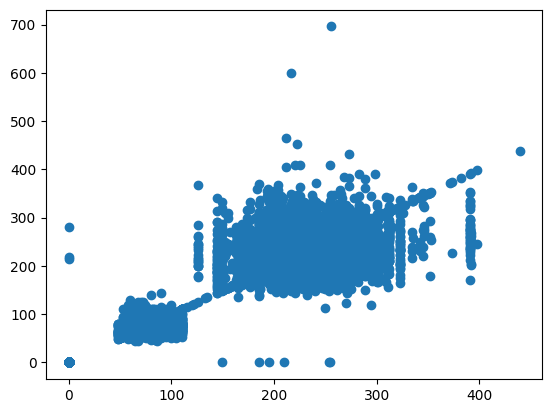

In [18]:
plt.scatter(pred,y)

<Axes: xlabel='age'>

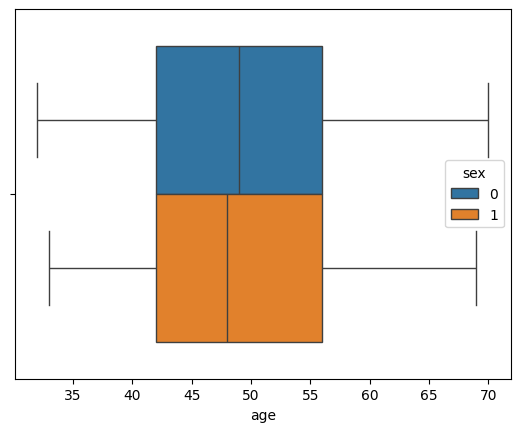

In [19]:
sns.boxplot(data=df,x='age',hue='sex')

<Axes: xlabel='sex', ylabel='age'>

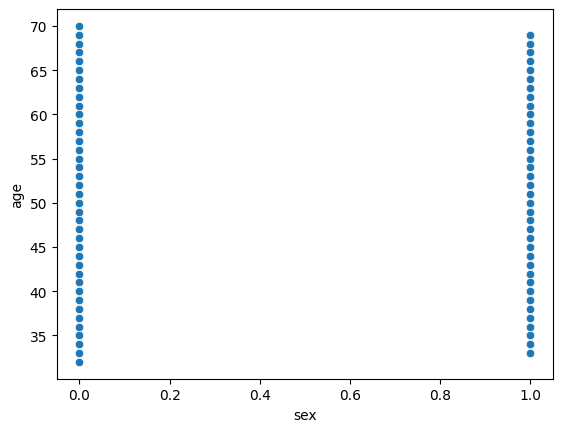

In [20]:
sns.scatterplot(data=df,x='sex',y='age')

<Axes: xlabel='age', ylabel='heart_rate'>

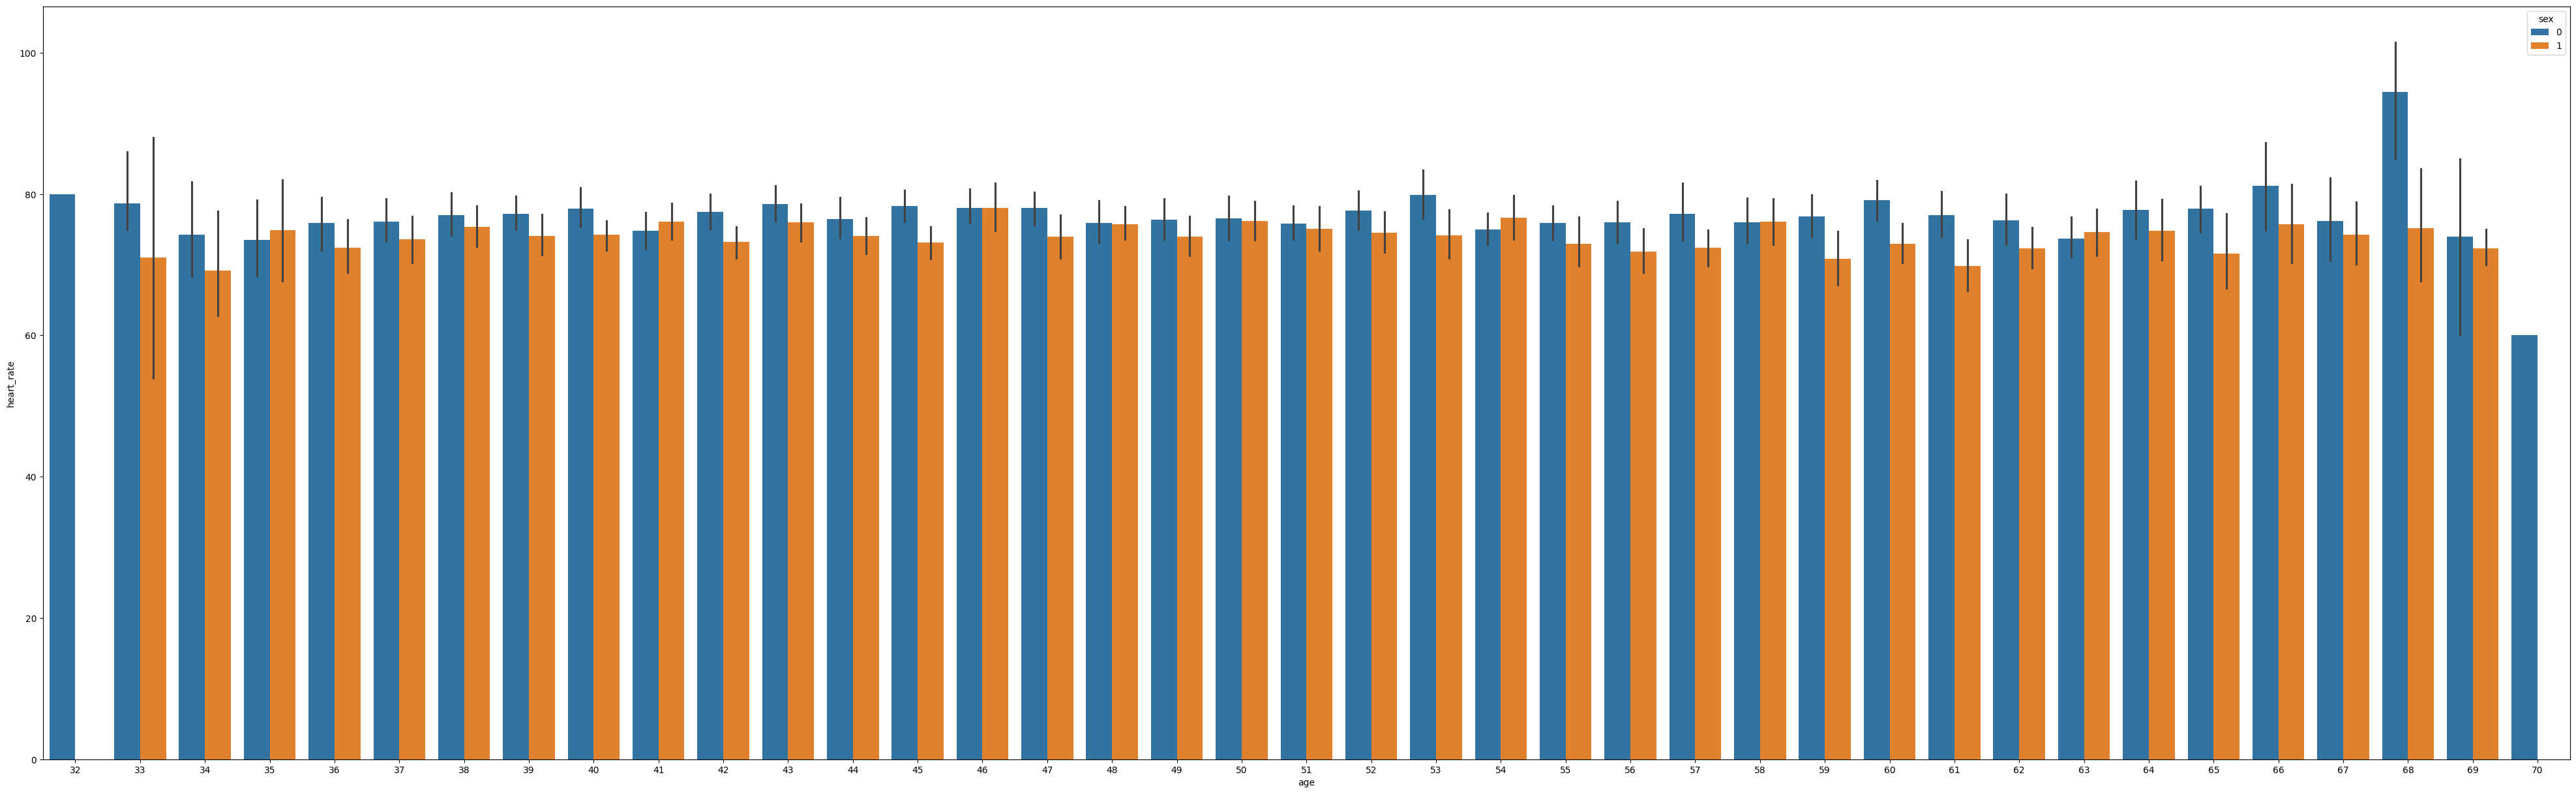

In [21]:
plt.figure(figsize=(50,15))
sns.barplot(data=df,x='age',y='heart_rate',hue='sex')

<Axes: xlabel='cigs_per_day', ylabel='age'>

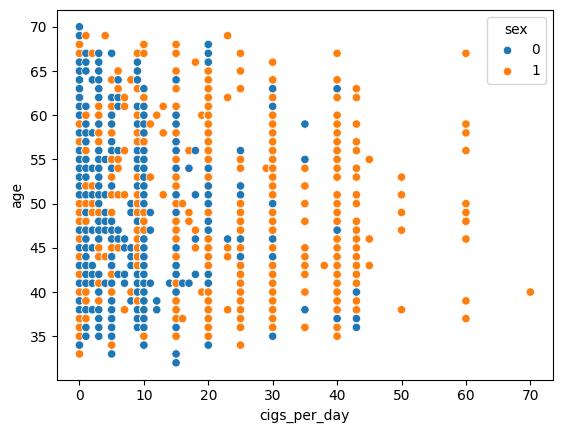

In [22]:
sns.scatterplot(data=df,y='age',x='cigs_per_day',hue='sex')

In [36]:
df.isnull().sum()

Unnamed: 0        0
age               0
sex               0
current_smoker    0
heart_rate        0
blood_pressure    0
cigs_per_day      0
chol              0
dtype: int64

In [24]:
df.head()

,Unnamed: 0,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,0,54,1,1,95,NaN,NaN,219.0
1,1,45,1,1,64,NaN,NaN,248.0
2,2,58,1,1,81,NaN,NaN,235.0
3,3,42,1,1,90,NaN,NaN,225.0
4,4,42,1,1,62,NaN,NaN,226.0


graph

In [25]:
X.head()

,age,sex,current_smoker,cigs_per_day
0,54,1,1,0.0
1,45,1,1,0.0
2,58,1,1,0.0
3,42,1,1,0.0
4,42,1,1,0.0


In [26]:
y.head()

,heart_rate,blood_pressure,chol
0,95,0.0,219.0
1,64,0.0,248.0
2,81,0.0,235.0
3,90,0.0,225.0
4,62,0.0,226.0


In [27]:
pickle.dump(mod,open('model.pkl','wb'))

In [28]:
model=pickle.load(open('model.pkl','rb'))

In [29]:
my=model.predict(X)

In [30]:
my

array([[ 95.,   0., 219.],
       [ 83.,   0., 170.],
       [ 81.,   0., 235.],
       ...,
       [ 70.,   0., 246.],
       [ 85.,   0., 340.],
       [ 98.,   0., 210.]], shape=(3900, 3))